In [1]:
# ============================================================
# CELL 1 — Imports & Config
# ============================================================
import pandas as pd
import re
import matplotlib.pyplot as plt

DATASET_PATH = "csv/train.csv"

df = pd.read_csv(DATASET_PATH)
df = df.dropna(subset=['prompt', 'svg'])
print(f"Total samples: {len(df)}")

Total samples: 50000


In [2]:
# ============================================================
# CELL 2 — Define all filters
# ============================================================

FORBIDDEN_TAGS = ['script', 'animate', 'animateTransform', 'animateMotion',
                  'set', 'foreignObject', 'iframe', 'video', 'audio']

def check_sample(svg):
    svg = str(svg).strip()
    reasons = []

    # 1. Length
    if len(svg) > 8000:
        reasons.append("too_long")

    # 2. Repetition
    window, threshold = 40, 3
    looping = False
    for i in range(len(svg) - window):
        if svg.count(svg[i:i+window]) >= threshold:
            looping = True
            break
    if looping:
        reasons.append("repetition")

    # 3. Path count
    if len(re.findall(r'<path', svg, re.IGNORECASE)) > 256:
        reasons.append("too_many_paths")

    # 4. Forbidden tags
    for tag in FORBIDDEN_TAGS:
        if re.search(rf'<{tag}[\s>]', svg, re.IGNORECASE):
            reasons.append(f"forbidden_tag:{tag}")
            break

    # 5. Must start with <svg
    if not svg.startswith('<svg'):
        reasons.append("no_svg_open")

    # 6. Must end with </svg>
    if not svg.endswith('</svg>'):
        reasons.append("no_svg_close")

    return reasons

print("Running checks...")
df['issues'] = df['svg'].apply(check_sample)
df['is_valid'] = df['issues'].apply(lambda x: len(x) == 0)
print("✅ Done")

Running checks...
✅ Done


In [3]:
# ============================================================
# CELL 3 — Summary
# ============================================================
total = len(df)
valid = df['is_valid'].sum()
invalid = total - valid

print(f"{'='*40}")
print(f"Total samples:   {total:>6}")
print(f"Valid samples:   {valid:>6} ({valid/total*100:.1f}%)")
print(f"Invalid samples: {invalid:>6} ({invalid/total*100:.1f}%)")
print(f"{'='*40}\n")

# Break down by issue type
all_issues = [issue for issues in df['issues'] for issue in issues]
issue_counts = pd.Series(all_issues).value_counts()
print("Issues breakdown:")
for issue, count in issue_counts.items():
    print(f"  {issue:<30} {count:>6} ({count/total*100:.1f}%)")

Total samples:    50000
Valid samples:    33000 (66.0%)
Invalid samples:  17000 (34.0%)

Issues breakdown:
  repetition                      16960 (33.9%)
  too_long                          100 (0.2%)
  too_many_paths                      1 (0.0%)


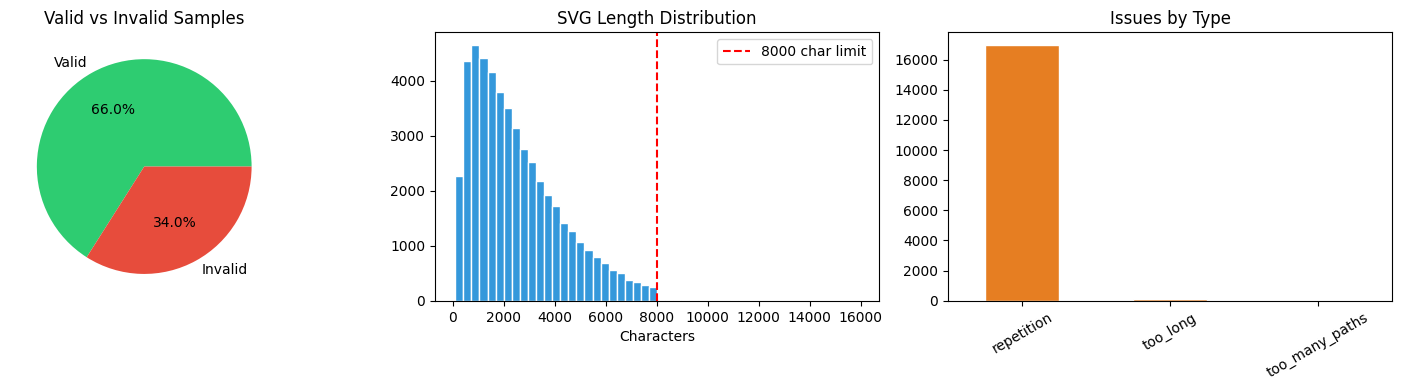

✅ Chart saved to data_quality.png


In [4]:
# ============================================================
# CELL 4 — Visualize
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Valid vs invalid pie
axes[0].pie([valid, invalid], labels=['Valid', 'Invalid'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%')
axes[0].set_title('Valid vs Invalid Samples')

# SVG length distribution
df['svg_len'] = df['svg'].str.len()
axes[1].hist(df['svg_len'], bins=50, color='#3498db', edgecolor='white')
axes[1].axvline(x=8000, color='red', linestyle='--', label='8000 char limit')
axes[1].set_title('SVG Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].legend()

# Issue type bar chart
if len(issue_counts) > 0:
    issue_counts.plot(kind='bar', ax=axes[2], color='#e67e22', edgecolor='white')
    axes[2].set_title('Issues by Type')
    axes[2].set_xlabel('')
    axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data_quality.png')
plt.show()
print("✅ Chart saved to data_quality.png")

In [6]:
# ============================================================
# CELL 5 — Sample invalid SVGs
# ============================================================
print("Sample INVALID SVGs and their issues:\n")
invalid_df = df[~df['is_valid']].head(5)
for _, row in invalid_df.iterrows():
    print(f"Prompt: {row['prompt']}")
    print(f"Issues: {row['issues']}")
    print(f"SVG preview: {str(row['svg'])}")
    print()

print("\nSample VALID SVGs:\n")
valid_df = df[df['is_valid']].head(3)
for _, row in valid_df.iterrows():
    print(f"Prompt: {row['prompt']}")
    print(f"SVG length: {len(str(row['svg']))} chars")
    print(f"SVG preview: {str(row['svg'])}")
    print()

Sample INVALID SVGs and their issues:

Prompt: The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.
Issues: ['repetition']
SVG preview: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#FF6A00" fill-opacity="1.0"  filling="0" d="M93.30000305175781 21.20000457763672 L93.30000305175781 80.4000015258789 L21.20000457763672 80.4000015258789 L21.20000457763672 179.60000610351562 L120.4000015258789 179.60000610351562 L120.4000015258789 107.0999984741211 L179.10000610351562 107.0999984741211 L179.10000610351562 21.20000457763672 L93.30000305175781 21.20000457763672 Z M113.80000305175781 172.89999389648438 L27.900001525878906 172.89999389648438 L27.900001525878906 87.0999984741211 L113.69999694824219 87.0999984741211 L113.69999694824219 172.89999389648438 L113.80000305175781 172.89999389648438 Z M172.5 100.39999389648438 L120.4000015258789 100.39999389648438 L1

In [7]:
# ============================================================
# CELL 6 — Save clean dataset
# ============================================================
clean_df = df[df['is_valid']][['prompt', 'svg']]
clean_df.to_csv('csv/train_clean.csv', index=False)
print(f"✅ Clean dataset saved to csv/train_clean.csv")
print(f"   {len(clean_df)} samples ready for training")

✅ Clean dataset saved to csv/train_clean.csv
   33000 samples ready for training
